# BME280 — topologia geografica Edge e workload sperimentale

Il dataset di partenza è costituito da osservazioni Sensor.Community provenienti da sensori BME280 distribuiti a livello mondiale. Il notebook considera le osservazioni comprese nella finestra temporale di gennaio 2025 e utilizza i sensori dotati di coordinate geografiche valide.

Lo scenario applicativo è limitato all'Europa. La topologia Edge viene derivata dall'intera popolazione di sensori europei localizzabili, prima della costruzione del workload sperimentale.

Le coordinate geografiche WGS84 (EPSG:4326) vengono proiettate nel sistema metrico europeo EPSG:3035 e utilizzate per individuare le zone di competenza degli Edge Site mediante K-Means. Il numero di cluster viene scelto massimizzando il Silhouette Score nell'intervallo di valori analizzato; inertia e metriche di dispersione geografica vengono utilizzate come indicatori diagnostici. La procedura seleziona una topologia composta da 13 Edge Site.

Dopo aver fissato la topologia, viene costruito un workload sperimentale di 150 sensori, distribuiti in modo pressoché uniforme tra gli Edge. All'interno di ciascuna zona, i sensori vengono selezionati casualmente senza sostituzione utilizzando un seed fisso, così da rendere il risultato riproducibile.

Il notebook esporta la topologia relativa al workload sperimentale e genera direttamente dal dataset sorgente uno shard di replay per ciascun Edge Site. Gli shard contengono esclusivamente le osservazioni dei sensori selezionati e costituiscono le trace utilizzate dai Simulator durante gli esperimenti.

## 0. Preparazione

Da PowerShell, nella root del repository:

```powershell
python -m venv .venv
.\.venv\Scripts\Activate.ps1
python -m pip install -r .\notebooks\requirements.txt
Set-Location .\notebooks
jupyter lab
```

In [1]:
from pathlib import Path
import os

# Limita il parallelismo utilizzato da K-Means su Windows.
# Le variabili devono essere impostate prima di importare NumPy e scikit-learn.
if os.name == 'nt':
    os.environ['OMP_NUM_THREADS'] = '1'
    os.environ['MKL_NUM_THREADS'] = '1'
    os.environ['LOKY_MAX_CPU_COUNT'] = '1'

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyproj import Transformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option(
    'display.float_format',
    lambda value: f'{value:,.3f}',
)
plt.style.use('seaborn-v0_8-whitegrid')

PROJECT_ROOT = Path.cwd().parent
DATASET_ROOT = PROJECT_ROOT / 'dataset'

In [2]:
DATASET_MONTH = '2025-01'
SENSOR_MODEL = 'bme280'

DATASET_FILENAME = f'{DATASET_MONTH}_{SENSOR_MODEL}.csv'
CSV_SEPARATOR = ';'
SCAN_CHUNK_ROWS = 500_000

TIME_WINDOW_START = pd.Timestamp(f'{DATASET_MONTH}-01T00:00:00Z')
TIME_WINDOW_END = (TIME_WINDOW_START+pd.offsets.MonthBegin(1))
SECONDS_PER_DAY = 86_400
CSV_PATH = DATASET_ROOT / DATASET_FILENAME

if not CSV_PATH.is_file():
    raise FileNotFoundError(
        f'Dataset non trovato: {CSV_PATH}'
    )

WINDOW_DAYS = (
    TIME_WINDOW_END - TIME_WINDOW_START
).total_seconds() / SECONDS_PER_DAY

## 1. Struttura del dataset di input

Prima dell'elaborazione vengono mostrate le colonne del dataset sorgente e alcune righe di esempio, così da documentarne la struttura e la rappresentazione originale dei valori.

L'anteprima ha esclusivamente uno scopo descrittivo e può contenere osservazioni esterne alla finestra temporale analizzata. Il parsing e il filtro dei timestamp vengono applicati durante la successiva scansione completa del dataset.


In [3]:
dataset_preview = pd.read_csv(
    CSV_PATH,
    sep=CSV_SEPARATOR,
    dtype='string',
    nrows=5,
    low_memory=False,
)

pd.DataFrame({'colonna': dataset_preview.columns})

,colonna
0,sensor_id
1,sensor_type
2,location
3,lat
4,lon
5,timestamp
6,pressure
7,altitude
8,pressure_sealevel
9,temperature


### Prime righe

In [4]:
dataset_preview.head()

,sensor_id,sensor_type,location,lat,lon,timestamp,pressure,altitude,pressure_sealevel,temperature,humidity
0,79419,BME280,68866,49.902,8.680,'2024-12-20 21:41:16',999.34,<NA>,<NA>,18.03,74.04
1,30343,BME280,17145,49.902,8.680,'2024-12-22 19:31:20',101540,<NA>,<NA>,0,52
2,47712,BME280,57457,51.634,5.886,2025-01-01T01:09:58,100400,<NA>,<NA>,8.6,85.1
3,48757,BME280,34554,51.60474072,5.87020530,2025-01-01T01:10:44,101300,<NA>,<NA>,7.9,93.8
4,88745,BME280,80338,47.870,18.180,2025-01-01T01:11:15,101875.34,<NA>,<NA>,11.30,48.53


## 2. Scansione e qualità dei dati

Il dataset viene analizzato mediante una scansione a chunk, così da non dover caricare l'intero CSV in memoria.

Per ogni blocco vengono interpretati i timestamp e mantenute esclusivamente le osservazioni appartenenti alla finestra temporale configurata. Durante la scansione vengono inoltre registrati gli estremi temporali osservati nel file e quelli effettivamente utilizzati dopo il filtro.

La distinzione è rilevante perché il CSV sorgente contiene anche osservazioni precedenti a gennaio 2025, come visibile nell'anteprima iniziale, mentre il notebook considera per l'analisi soltanto la finestra temporale configurata.

Parallelamente viene effettuato un controllo sulla presenza di valori nelle colonne del dataset e vengono accumulate le informazioni necessarie a costruire la popolazione geografica dei sensori a partire da `sensor_id`, `lat` e `lon`.

### Filtro temporale

I timestamp vengono ripuliti dalle eventuali differenze di rappresentazione presenti nel CSV e convertiti in un formato temporale uniforme in UTC. Per ogni chunk vengono conservate le sole osservazioni comprese nell’intervallo [`TIME_WINDOW_START`, `TIME_WINDOW_END`).


In [5]:
def filter_chunk_by_time(chunk, time_start, time_end):
    timestamp_text = (
        chunk['timestamp']
        .str.strip()
        .str.strip("'\"")
    )

    timestamps = pd.to_datetime(
        timestamp_text,
        format='mixed',
        utc=True,
    )

    in_time_window = (
        timestamps.ge(time_start)
        & timestamps.lt(time_end)
    )

    filtered_chunk = chunk.loc[in_time_window].copy()

    metadata = {
        'observed_timestamp_min': timestamps.min(),
        'observed_timestamp_max': timestamps.max(),
        'retained_timestamp_min': (
            timestamps.loc[in_time_window].min()
            if in_time_window.any()
            else None
        ),
        'retained_timestamp_max': (
            timestamps.loc[in_time_window].max()
            if in_time_window.any()
            else None
        ),
    }

    return filtered_chunk, metadata

### Conteggio dei valori validi

Per ciascuna colonna viene conteggiato il numero di valori effettivamente presenti nella finestra temporale analizzata. Stringhe vuote e rappresentazioni testuali comuni di valori mancanti vengono considerate nulle.

Questi conteggi vengono utilizzati per descrivere la qualità del dataset e supportare la successiva selezione delle variabili necessarie alle diverse fasi dello studio.

In [6]:
NULL_LIKE_VALUES = {
    '',
    'null',
    '<null>',
    'none',
    'nan',
}


def count_valid_column_values(frame):
    counts = {}

    for column_name in frame.columns:
        values = frame[column_name]

        normalized = (
            values
            .astype('string')
            .str.strip()
            .str.lower()
        )

        valid = (
            normalized.notna()
            & ~normalized.isin(NULL_LIKE_VALUES)
        )

        counts[column_name] = int(valid.sum())

    return pd.Series(counts, dtype='int64')

In [7]:
# Aggiorna gli estremi temporali globali combinando i minimi e massimi osservati nei diversi chunk
def update_timestamp_bounds(
    current_min,
    current_max,
    new_min,
    new_max,
):
    if new_min is not None:
        current_min = (
            new_min
            if current_min is None
            else min(current_min, new_min)
        )

    if new_max is not None:
        current_max = (
            new_max
            if current_max is None
            else max(current_max, new_max)
        )

    return current_min, current_max

### Aggregazione della popolazione dei sensori

Le coordinate vengono convertite in formato numerico e validate rispetto agli intervalli geografici ammessi. Vengono inoltre escluse dal calcolo delle coordinate le posizioni prossime a `(0, 0)`, considerate non informative.

Le osservazioni valide vengono quindi aggregate per `sensor_id`, accumulando il numero di righe disponibili e le somme di latitudine e longitudine. Queste informazioni verranno successivamente combinate tra i diversi chunk per ottenere una singola posizione rappresentativa per ciascun sensore.

In [8]:
def aggregate_sensor_chunk(chunk):
    sensor_ids = chunk['sensor_id'].str.strip()

    valid_sensor_id = (sensor_ids.notna()& sensor_ids.ne(''))

    latitudes = pd.to_numeric(chunk['lat'],errors='coerce')

    longitudes = pd.to_numeric(chunk['lon'],errors='coerce')

    valid_coordinates = (
        latitudes.between(-90, 90)
        & longitudes.between(-180, 180)
        & ~(
            latitudes.abs().lt(0.01)
            & longitudes.abs().lt(0.01)
        )
    ).fillna(False)

    sensor_rows = pd.DataFrame({
        'sensor_id': sensor_ids,
        'lat': latitudes.where(valid_coordinates),
        'lon': longitudes.where(valid_coordinates),
    }).loc[valid_sensor_id]

    # Statistiche parziali per sensore, successivamente combinabili tra i diversi chunk
    sensor_stats = (
        sensor_rows
        .groupby('sensor_id', as_index=False)
        .agg(
            rows=('sensor_id', 'size'),
            coordinate_rows=('lat', 'count'),
            lat_sum=('lat', 'sum'),
            lon_sum=('lon', 'sum'),
        )
    )

    metadata = {
        'invalid_sensor_id_rows': int(
            (~valid_sensor_id).sum()
        ),
        'invalid_coordinate_rows': int(
            (~valid_coordinates).sum()
        ),
    }

    return sensor_stats, metadata

### Scansione completa del CSV

La funzione seguente coordina la scansione chunked dell'intero dataset. Per ogni blocco:

- applica il filtro temporale;
- aggiorna gli estremi temporali globali;
- conta i valori presenti nelle diverse colonne;
- valida identificativi e coordinate;
- accumula per ciascun sensore conteggi e somme delle coordinate, successivamente combinati tra i chunk per ottenere le statistiche complessive e una posizione geografica rappresentativa.

Al termine della scansione, le statistiche ottenute dai diversi chunk vengono concatenate e vengono restituiti anche i metadati complessivi del dataset.

In [9]:
def scan_sensor_dataset(csv_path,time_start,time_end, chunk_rows, separator):
    chunk_aggregates = []

    # Contatori globali della scansione
    raw_rows = 0
    retained_rows = 0

    # Estremi temporali osservati nel CSV e nella sola finestra utilizzata
    observed_timestamp_min = None
    observed_timestamp_max = None
    retained_timestamp_min = None
    retained_timestamp_max = None

    # Contatori delle righe problematiche.
    invalid_sensor_id_rows = 0
    invalid_coordinate_rows = 0

    # Conteggio cumulativo dei valori validi per ciascuna colonna
    column_valid_counts = None

    # Lettura del CSV a chunk per evitare di caricare l'intero dataset in memoria
    for chunk in pd.read_csv(csv_path,sep=separator,dtype='string',chunksize=chunk_rows,low_memory=False):
        raw_rows += len(chunk)

        # Applica il filtro temporale e raccoglie gli estremi del chunk
        filtered_chunk, time_metadata = filter_chunk_by_time(
            chunk,
            time_start,
            time_end,
        )

        # Aggiorna gli estremi temporali globali osservati nel file
        observed_timestamp_min, observed_timestamp_max = (
            update_timestamp_bounds(
                observed_timestamp_min,
                observed_timestamp_max,
                time_metadata['observed_timestamp_min'],
                time_metadata['observed_timestamp_max'],
            )
        )

        # Aggiorna gli estremi temporali globali delle sole righe trattenute
        retained_timestamp_min, retained_timestamp_max = (
            update_timestamp_bounds(
                retained_timestamp_min,
                retained_timestamp_max,
                time_metadata['retained_timestamp_min'],
                time_metadata['retained_timestamp_max'],
            )
        )

        # I chunk senza osservazioni nella finestra temporale non richiedono ulteriori elaborazioni
        if filtered_chunk.empty:
            continue

        retained_rows += len(filtered_chunk)

        # Aggiorna il numero di valori validi presenti in ciascuna colonna
        chunk_column_counts = count_valid_column_values(
            filtered_chunk
        )

        if column_valid_counts is None:
            column_valid_counts = chunk_column_counts
        else:
            column_valid_counts = column_valid_counts.add(
                chunk_column_counts,
                fill_value=0,
            )

        # Produce statistiche parziali per sensore sul chunk corrente
        chunk_stats, sensor_metadata = aggregate_sensor_chunk(filtered_chunk)

        # Accumula i contatori relativi a identificativi e coordinate non validi
        invalid_sensor_id_rows += (sensor_metadata['invalid_sensor_id_rows'])

        invalid_coordinate_rows += (sensor_metadata['invalid_coordinate_rows'])

        chunk_aggregates.append(chunk_stats)

    if not chunk_aggregates:
        raise RuntimeError(
            'Nessuna osservazione valida trovata '
            'nella finestra temporale configurata.'
        )

    # Le statistiche dei singoli chunk vengono riunite per la successiva aggregazione globale per sensore
    sensor_chunk_stats = pd.concat(chunk_aggregates,ignore_index=True)

    # Metadati complessivi prodotti durante la scansione
    scan_metadata = {
        'raw_rows': raw_rows,
        'retained_rows': retained_rows,
        'invalid_sensor_id_rows': invalid_sensor_id_rows,
        'invalid_coordinate_rows': invalid_coordinate_rows,
        'observed_timestamp_min': observed_timestamp_min,
        'observed_timestamp_max': observed_timestamp_max,
        'retained_timestamp_min': retained_timestamp_min,
        'retained_timestamp_max': retained_timestamp_max,
        'column_valid_counts': column_valid_counts,
    }

    return sensor_chunk_stats, scan_metadata

In [10]:
sensor_chunk_stats, scan_metadata = scan_sensor_dataset(
    csv_path=CSV_PATH,
    time_start=TIME_WINDOW_START,
    time_end=TIME_WINDOW_END,
    chunk_rows=SCAN_CHUNK_ROWS,
    separator=CSV_SEPARATOR,
)

### Completezza delle colonne

A partire dai conteggi raccolti durante la scansione viene analizzata la completezza delle colonne nella finestra temporale considerata.

Per ciascuna variabile vengono riportati il numero di valori presenti, il numero di valori mancanti e la relativa percentuale di completezza. Stringhe vuote e comuni rappresentazioni testuali di valori mancanti vengono considerate nulle.

Questa analisi ha uno scopo descrittivo. La scelta delle colonne utilizzate dal replay viene effettuata successivamente in base alle informazioni richieste dall'applicazione.

In [11]:
column_quality = pd.DataFrame({
    'column':
        scan_metadata['column_valid_counts'].index,

    'valid_rows':
        scan_metadata['column_valid_counts'].values,
})

column_quality['missing_rows'] = (
    scan_metadata['retained_rows']
    - column_quality['valid_rows']
)

column_quality['valid_pct'] = (
    100
    * column_quality['valid_rows']
    / scan_metadata['retained_rows']
)

column_quality

,column,valid_rows,missing_rows,valid_pct
0,sensor_id,80222754,0,100.000
1,sensor_type,80222754,0,100.000
2,location,80222754,0,100.000
3,lat,80222754,0,100.000
4,lon,80222754,0,100.000
5,timestamp,80222754,0,100.000
6,pressure,80016768,205986,99.743
7,altitude,0,80222754,0.000
8,pressure_sealevel,0,80222754,0.000
9,temperature,80023198,199556,99.751


### Selezione delle variabili

Dall'analisi di completezza si osserva che `altitude` e `pressure_sealevel` sono completamente prive di valori e non vengono utilizzate nelle elaborazioni successive.

La costruzione della popolazione geografica utilizza `sensor_id`, `timestamp`, `lat` e `lon`: il timestamp permette di applicare la finestra temporale, mentre latitudine e longitudine vengono utilizzate per determinare la posizione dei sensori.

Il dataset di replay utilizza invece `sensor_id`, `timestamp`, `pressure`, `temperature` e `humidity`.

`sensor_type` e `location`, pur essendo presenti nel dataset sorgente, non sono necessari nelle elaborazioni successive.

In [12]:

REPLAY_COLUMNS = [
    'sensor_id',
    'timestamp',
    'pressure',
    'temperature',
    'humidity',
]

### Riepilogo della scansione

Il riepilogo seguente sintetizza le principali caratteristiche del dataset sorgente e della porzione effettivamente utilizzata nell'analisi.

In particolare, il confronto tra gli estremi temporali osservati e quelli utilizzati rende esplicito il filtro applicato al CSV originale, mentre i conteggi delle righe permettono di quantificare quante osservazioni ricadano nella finestra temporale configurata.

In [13]:
outside_time_window_rows = (
    scan_metadata['raw_rows']
    - scan_metadata['retained_rows']
)

dataset_summary = pd.Series({
    'dimensione_csv_GB':
        CSV_PATH.stat().st_size / 1e9,

    'righe_nel_csv_fisico':
        scan_metadata['raw_rows'],

    'righe_nella_finestra_temporale':
        scan_metadata['retained_rows'],

    'righe_fuori_finestra_temporale':
        outside_time_window_rows,

    'righe_sensor_id_non_valido':
        scan_metadata['invalid_sensor_id_rows'],

    'righe_coordinate_non_valide':
        scan_metadata['invalid_coordinate_rows'],

    'timestamp_minimo_osservato':
        scan_metadata['observed_timestamp_min'],

    'timestamp_massimo_osservato':
        scan_metadata['observed_timestamp_max'],

    'timestamp_minimo_utilizzato':
        scan_metadata['retained_timestamp_min'],

    'timestamp_massimo_utilizzato':
        scan_metadata['retained_timestamp_max'],

    'durata_finestra_configurata_giorni':
        WINDOW_DAYS,

    'sensori_unici':
        sensor_chunk_stats['sensor_id'].nunique(),
})

dataset_summary.to_frame('valore')

,valore
dimensione_csv_GB,6.363
righe_nel_csv_fisico,80222756
righe_nella_finestra_temporale,80222754
righe_fuori_finestra_temporale,2
righe_sensor_id_non_valido,0
righe_coordinate_non_valide,283499
timestamp_minimo_osservato,2024-12-20 21:41:16+00:00
timestamp_massimo_osservato,2025-01-29 23:59:59+00:00
timestamp_minimo_utilizzato,2025-01-01 01:09:58+00:00
timestamp_massimo_utilizzato,2025-01-29 23:59:59+00:00


## 3. Costruzione della popolazione di sensori localizzabili

Le statistiche parziali calcolate nei singoli chunk vengono ricomposte per `sensor_id`, ottenendo una singola riga per ciascun sensore osservato nella finestra temporale.

Per ogni sensore vengono calcolati:

- il numero complessivo di osservazioni;
- il numero di osservazioni associate a coordinate valide;
- una posizione geografica rappresentativa, ottenuta come media delle coordinate valide;
- il numero medio di osservazioni giornaliere (`rows_per_day`).

Le somme delle coordinate e i relativi conteggi vengono combinati tra i chunk prima di calcolare la media, evitando quindi di effettuare una media delle medie dei singoli blocchi.

Vengono infine esclusi i sensori per i quali non è disponibile alcuna coordinata utilizzabile.

Il risultato rappresenta ancora la popolazione mondiale dei sensori localizzabili; il filtro geografico europeo viene applicato nella sezione successiva.

In [14]:
# Ricompone le statistiche parziali prodotte nei diversi chunk
sensor_stats = (
    sensor_chunk_stats
    .groupby('sensor_id', as_index=False)
    .agg(
        rows=('rows', 'sum'),
        coordinate_rows=('coordinate_rows', 'sum'),
        lat_sum=('lat_sum', 'sum'),
        lon_sum=('lon_sum', 'sum'),
    )
)

# Posizione media calcolata sulle sole osservazioni associate a coordinate valide
sensor_stats['lat'] = (
    sensor_stats['lat_sum']
    / sensor_stats['coordinate_rows']
)

sensor_stats['lon'] = (
    sensor_stats['lon_sum']
    / sensor_stats['coordinate_rows']
)

# Frequenza media naturale delle osservazioni
sensor_stats['rows_per_day'] = (
    sensor_stats['rows']
    / WINDOW_DAYS
)

# Mantiene soltanto i sensori per cui è disponibile almeno una posizione geografica utilizzabile
located_sensors = (
    sensor_stats.loc[
        sensor_stats['coordinate_rows'].gt(0),
        [
            'sensor_id',
            'rows',
            'lat',
            'lon',
            'rows_per_day',
        ],
    ]
    .dropna(subset=['lat', 'lon'])
    .copy()
    .reset_index(drop=True)
)
sensor_filter_summary = pd.Series({
    'sensori_totali':
        len(sensor_stats),

    'sensori_senza_coordinate_utilizzabili':
        len(sensor_stats) - len(located_sensors),

    'sensori_localizzabili':
        len(located_sensors),
})

sensor_filter_summary.to_frame('valore')

,valore
sensori_totali,5306
sensori_senza_coordinate_utilizzabili,18
sensori_localizzabili,5288


## 4. Popolazione europea e proiezione geografica

A partire dalla popolazione mondiale dei sensori localizzabili viene selezionato lo scenario geografico di interesse mediante un bounding box che approssima l'area europea.

Il filtro utilizza esclusivamente latitudine e longitudine e non ricostruisce i confini politici o geografici esatti dell'Europa. Il suo scopo è delimitare in modo semplice e riproducibile la popolazione utilizzata per la successiva costruzione della topologia Edge.

In questa fase viene mantenuta l'intera popolazione ricadente nell'area selezionata: nessun sensore viene ancora scelto per il workload sperimentale.

Le coordinate originali sono espresse in latitudine e longitudine secondo il sistema WGS84 (`EPSG:4326`). Questi valori sono angoli espressi in gradi e non rappresentano direttamente distanze lineari: inoltre, una variazione di un grado di longitudine non corrisponde alla stessa distanza fisica a latitudini diverse.

Poiché il clustering K-Means utilizza distanze euclidee, le coordinate geografiche non vengono utilizzate direttamente come feature. Vengono invece proiettate nel sistema `EPSG:3035`, ottenendo coordinate cartesiane metriche adatte all'analisi spaziale sull'area europea.

Le coordinate proiettate vengono memorizzate come `x_m` e `y_m`. Queste due variabili costituiscono le feature geografiche utilizzate dal K-Means per raggruppare sensori spazialmente vicini.

In [15]:
EUROPE_BOUNDS = {
    'latitude_min': 34.0,
    'latitude_max': 72.0,
    'longitude_min': -25.0,
    'longitude_max': 45.0,
}

GEOGRAPHIC_CRS = 'EPSG:4326'
EUROPE_PROJECTED_CRS = 'EPSG:3035'

EUROPE_TRANSFORMER = Transformer.from_crs(
    GEOGRAPHIC_CRS,
    EUROPE_PROJECTED_CRS,
    always_xy=True,
)

In [16]:
def filter_european_population(frame, bounds):
    in_europe = (
        frame['lat'].between(
            bounds['latitude_min'],
            bounds['latitude_max'],
        )
        & frame['lon'].between(
            bounds['longitude_min'],
            bounds['longitude_max'],
        )
    )

    return (
        frame.loc[in_europe]
        .copy()
        .reset_index(drop=True)
    )


def add_projected_coordinates(frame, transformer):
    projected = frame.copy()

    easting_m, northing_m = transformer.transform(
        projected['lon'].to_numpy(),
        projected['lat'].to_numpy(),
    )

    projected['x_m'] = easting_m
    projected['y_m'] = northing_m

    return projected

In [17]:
europe_population = filter_european_population(
    frame=located_sensors,
    bounds=EUROPE_BOUNDS,
)

europe_population = add_projected_coordinates(
    frame=europe_population,
    transformer=EUROPE_TRANSFORMER,
)


europe_population_summary = pd.Series({
    'sensori_europei': len(europe_population),
    'latitudine_min': europe_population['lat'].min(),
    'latitudine_max': europe_population['lat'].max(),
    'longitudine_min': europe_population['lon'].min(),
    'longitudine_max': europe_population['lon'].max(),
    'righe_totali': europe_population['rows'].sum(),
    'eventi_giornalieri_medi_totali': (
        europe_population['rows_per_day'].sum()
    ),
})

europe_population_summary.to_frame('valore')

,valore
sensori_europei,"5,102.000"
latitudine_min,34.688
latitudine_max,68.386
longitudine_min,-9.494
longitudine_max,44.998
righe_totali,"76,888,330.000"
eventi_giornalieri_medi_totali,"2,480,268.710"


## 5. Ricerca del numero di zone Edge

Il clustering viene valutato sull'intera popolazione europea, prima della costruzione del workload sperimentale.

Per ogni valore di `k` compreso tra `K_EDGE_MIN` e `K_EDGE_MAX`, K-Means opera esclusivamente sulle coordinate geografiche proiettate `x_m` e `y_m`.

Il **Silhouette Score** costituisce il criterio principale per la scelta del numero di Edge: viene selezionato il valore di `k` che massimizza la qualità del clustering.

L'**elbow method** sull'inertia viene mantenuto come riferimento diagnostico, mentre il **raggio massimo** permette di osservare la dispersione geografica del cluster più esteso al variare di `k`.

In [18]:
RANDOM_STATE = 42
KMEANS_N_INIT = 20

K_EDGE_MIN = 5
K_EDGE_MAX = 15

KMEANS_FEATURES = [
    'x_m',
    'y_m',
]

In [19]:
def evaluate_edge_k(frame, k):
    features = frame[
        KMEANS_FEATURES
    ].to_numpy(dtype=float)

    model = KMeans(
        n_clusters=k,
        n_init=KMEANS_N_INIT,
        random_state=RANDOM_STATE,
    )

    labels = model.fit_predict(features)
    centroids = model.cluster_centers_

    distances = np.linalg.norm(
        features - centroids[labels],
        axis=1,
    )

    edge_radii = np.array([
        distances[labels == edge].max()
        for edge in range(k)
    ])

    metrics = {
        'k': k,
        'inertia': model.inertia_,
        'silhouette': silhouette_score(
            features,
            labels,
        ),
        'max_radius_m': edge_radii.max(),
    }

    return metrics, labels, centroids

### Stima diagnostica dell'Elbow

Come indicatore diagnostico viene stimato anche il punto di elbow della curva dell'inertia.

I valori di `k` e dell'inertia vengono normalizzati nell'intervallo `[0, 1]`. Il punto di elbow viene identificato come il punto della curva avente la maggiore distanza dalla retta che collega il primo e l'ultimo valore analizzati.

Questo valore non determina direttamente il numero di Edge, ma viene confrontato con la scelta ottenuta tramite Silhouette Score.

In [20]:
def detect_elbow(metrics):
    k_values = metrics['k'].to_numpy(dtype=float)
    inertia = metrics['inertia'].to_numpy(dtype=float)

    # Normalizzazione necessaria per confrontare le due dimensioni
    # indipendentemente dalle rispettive scale.
    normalized_k = (
        (k_values - k_values.min())
        / (k_values.max() - k_values.min())
    )

    normalized_inertia = (
        (inertia - inertia.min())
        / (inertia.max() - inertia.min())
    )

    points = np.column_stack([
        normalized_k,
        normalized_inertia,
    ])

    start = points[0]
    end = points[-1]

    line = end - start
    line_length = np.linalg.norm(line)

    offsets = points - start

    # Distanza di ciascun punto dalla retta che collega gli estremi.
    distances = np.abs(
        line[0] * offsets[:, 1]
        - line[1] * offsets[:, 0]
    ) / line_length

    elbow_index = int(np.argmax(distances))

    return int(k_values[elbow_index])

### Valutazione delle configurazioni candidate

Per ogni valore di `k` nell'intervallo configurato viene costruito un clustering indipendente e vengono raccolti il valore di inertia, il Silhouette Score e il raggio massimo.

Il numero finale di Edge viene scelto massimizzando il Silhouette Score. Il valore individuato dall'elbow method viene riportato separatamente come riferimento diagnostico.

In [21]:
edge_k_results = {}

metrics = []

for k in range(
    K_EDGE_MIN,
    K_EDGE_MAX + 1,
):
    k_metrics, labels, centroids = evaluate_edge_k(
        frame=europe_population,
        k=k,
    )

    metrics.append(k_metrics)

    edge_k_results[k] = {
        'labels': labels,
        'centroids': centroids,
    }

edge_k_metrics = pd.DataFrame(metrics)

### Confronto delle configurazioni candidate

Le configurazioni esplorate vengono confrontate attraverso tre indicatori:

- **Inertia**, utilizzata per visualizzare l'andamento dell'elbow method;
- **Silhouette Score**, utilizzato come criterio principale per la scelta del numero di Edge;
- **raggio massimo**, che descrive la dispersione geografica del cluster più esteso per ciascun valore di `k`.


In [22]:

elbow_k = detect_elbow(edge_k_metrics)

best_silhouette_index = (
    edge_k_metrics['silhouette'].idxmax()
)

selected_k_edge = int(
    edge_k_metrics.loc[
        best_silhouette_index,
        'k',
    ]
)

selected_k_metrics = (
    edge_k_metrics.loc[
        edge_k_metrics['k'].eq(selected_k_edge)
    ]
    .iloc[0]
)


print(f'Elbow diagnostico: k={elbow_k}')

print(
    f'Numero Edge selezionato: '
    f'k={selected_k_edge}'
)

print(
    f'Silhouette massima: '
    f'{selected_k_metrics["silhouette"]:.6f}'
)

selected_k_metrics

Elbow diagnostico: k=9
Numero Edge selezionato: k=13
Silhouette massima: 0.520981


k                               13.000
inertia        206,671,743,921,336.656
silhouette                       0.521
max_radius_m             1,166,965.524
Name: 8, dtype: float64

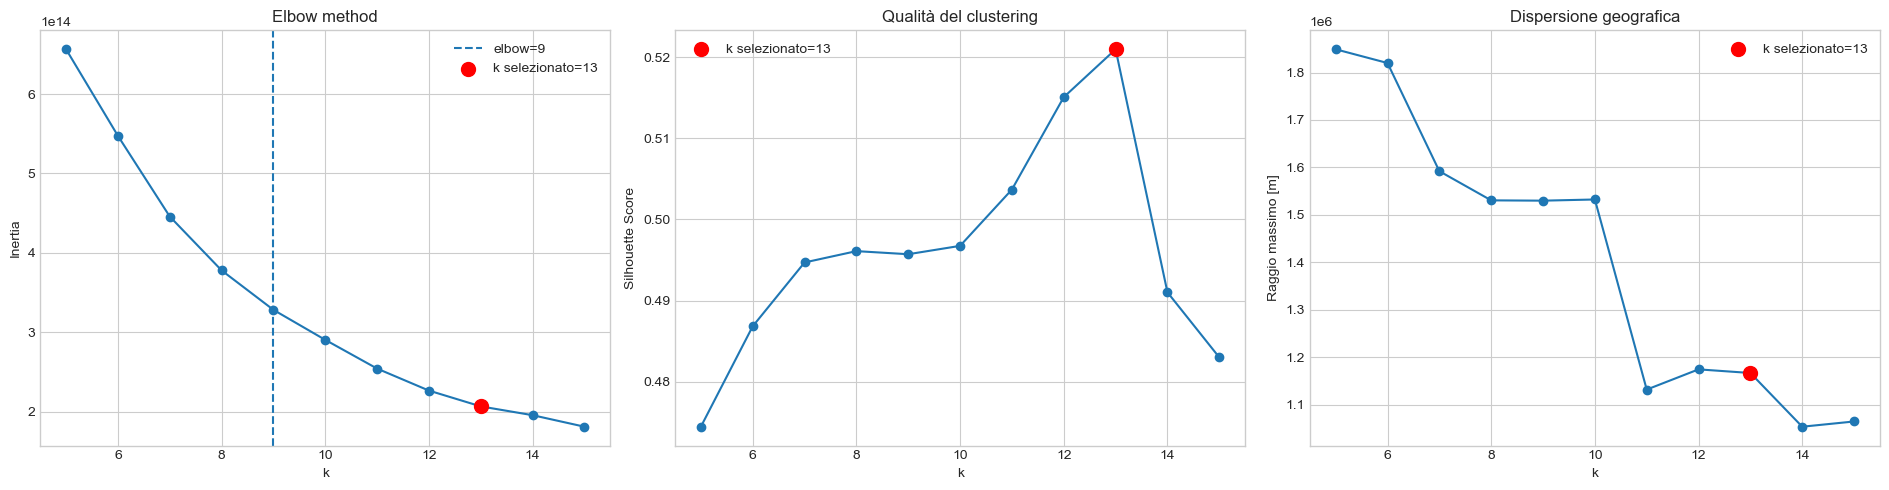

In [23]:
selected_inertia = selected_k_metrics['inertia']
selected_radius = selected_k_metrics['max_radius_m']

fig, axes = plt.subplots(
    1,
    3,
    figsize=(19, 5),
)

# Elbow
axes[0].plot(
    edge_k_metrics['k'],
    edge_k_metrics['inertia'],
    marker='o',
)

axes[0].axvline(
    elbow_k,
    linestyle='--',
    label=f'elbow={elbow_k}',
)

axes[0].scatter(
    selected_k_edge,
    selected_inertia,
    color='red',
    s=100,
    zorder=5,
    label=f'k selezionato={selected_k_edge}',
)

axes[0].set(
    xlabel='k',
    ylabel='Inertia',
    title='Elbow method',
)

axes[0].legend()

# Silhouette Score
axes[1].plot(
    edge_k_metrics['k'],
    edge_k_metrics['silhouette'],
    marker='o',
)

axes[1].scatter(
    selected_k_edge,
    selected_k_metrics['silhouette'],
    color='red',
    s=100,
    zorder=5,
    label=f'k selezionato={selected_k_edge}',
)

axes[1].set(
    xlabel='k',
    ylabel='Silhouette Score',
    title='Qualità del clustering',
)

axes[1].legend()

# Dispersione geografica
axes[2].plot(
    edge_k_metrics['k'],
    edge_k_metrics['max_radius_m'],
    marker='o',
)

axes[2].scatter(
    selected_k_edge,
    selected_radius,
    color='red',
    s=100,
    zorder=5,
    label=f'k selezionato={selected_k_edge}',
)

axes[2].set(
    xlabel='k',
    ylabel='Raggio massimo [m]',
    title='Dispersione geografica',
)

axes[2].legend()

plt.tight_layout()
plt.show()

## 6. Topologia Edge sulla popolazione europea

Dopo la selezione del numero di cluster, vengono recuperati i risultati del clustering già calcolato per `selected_k_edge` durante la valutazione delle configurazioni candidate.

La configurazione scelta non viene quindi ricalcolata: vengono riutilizzati direttamente le etichette e i centroidi già ottenuti durante la valutazione dei diversi valori di `k`.

Le etichette numeriche prodotte da K-Means non possiedono un significato geografico intrinseco. Per ottenere identificativi geografici stabili e facilmente interpretabili, i centroidi vengono quindi ordinati da ovest verso est e, a parità di coordinata orizzontale, da sud verso nord.

A ciascun sensore vengono associati l'identificativo numerico del cluster (`edge_cluster`) e l'identificativo logico dell'Edge (`edge_id`).

La topologia risultante rappresenta la suddivisione geografica dell'intera popolazione europea ed è definita prima della successiva selezione dei 150 sensori utilizzati nel workload sperimentale.

In [24]:
def stabilize_cluster_labels(
    labels,
    centroids,
):
    # Ordina i centroidi da ovest verso est e, a parità di coordinata x, da sud verso nord
    centroid_order = np.lexsort((
        centroids[:, 1],
        centroids[:, 0],
    ))

    raw_to_stable = np.empty(
        len(centroids),
        dtype=int,
    )

    raw_to_stable[centroid_order] = np.arange(
        len(centroids)
    )

    stable_labels = raw_to_stable[labels]
    stable_centroids = centroids[centroid_order]

    return stable_labels, stable_centroids

In [25]:


raw_labels = edge_k_results[
    selected_k_edge
]['labels']

raw_centroids = edge_k_results[
    selected_k_edge
]['centroids']

stable_labels, stable_centroids = (
    stabilize_cluster_labels(
        labels=raw_labels,
        centroids=raw_centroids,
    )
)

In [26]:
edge_centroids = pd.DataFrame({
    'edge_cluster': np.arange(
        selected_k_edge
    ),
    'edge_id': [
        f'edge-{edge}'
        for edge in range(selected_k_edge)
    ],
    'centroid_x_m': stable_centroids[:, 0],
    'centroid_y_m': stable_centroids[:, 1],
})

europe_topology = europe_population.copy()

europe_topology['edge_cluster'] = stable_labels

europe_topology['edge_id'] = [
    f'edge-{edge}'
    for edge in stable_labels
]

europe_topology.head()

,sensor_id,rows,lat,lon,rows_per_day,x_m,y_m,edge_cluster,edge_id
0,10006,16181,42.626,23.382,521.968,"5,415,687.141","2,266,583.879",9,edge-9
1,10008,16591,41.766,26.204,535.194,"5,661,796.603","2,218,443.038",9,edge-9
2,10060,13292,49.306,8.636,428.774,"4,221,790.708","2,911,254.778",3,edge-3
3,10079,16280,42.544,22.966,525.161,"5,383,504.046","2,251,632.381",9,edge-9
4,10097,16337,42.662,23.465,527.000,"5,421,753.407","2,271,753.983",9,edge-9


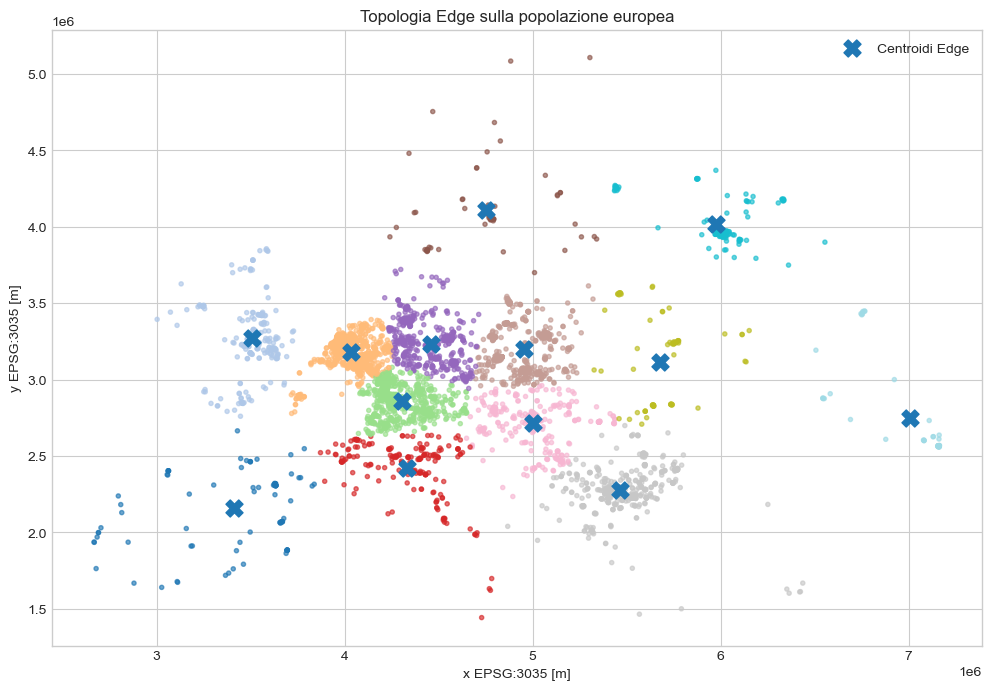

In [27]:
fig, ax = plt.subplots(
    figsize=(12, 8)
)

cmap = plt.get_cmap(
    'tab20',
    selected_k_edge,
)

ax.scatter(
    europe_topology['x_m'],
    europe_topology['y_m'],
    c=europe_topology['edge_cluster'],
    cmap=cmap,
    s=9,
    alpha=0.65,
)

ax.scatter(
    edge_centroids['centroid_x_m'],
    edge_centroids['centroid_y_m'],
    marker='X',
    s=150,
    label='Centroidi Edge',
)

ax.set(
    xlabel='x EPSG:3035 [m]',
    ylabel='y EPSG:3035 [m]',
    title='Topologia Edge sulla popolazione europea',
)

ax.legend()

plt.show()

## 7. Costruzione del workload sperimentale

La topologia Edge viene definita sull'intera popolazione europea, mentre gli esperimenti vengono eseguiti su un sottoinsieme di `EXPERIMENT_SENSOR_COUNT` sensori.

Il workload non viene campionato proporzionalmente alla densità della popolazione originale. L'obiettivo è invece garantire una rappresentazione comparabile di tutte le zone Edge, evitando che le aree geograficamente più dense dominino automaticamente gli esperimenti.

Il numero di sensori viene quindi suddiviso nel modo più uniforme possibile tra gli Edge. Una quota base viene assegnata a tutte le zone e gli eventuali sensori residui vengono attribuiti agli Edge con popolazione maggiore.

All'interno di ciascun Edge i sensori vengono selezionati casualmente senza sostituzione utilizzando un seed fisso, rendendo la costruzione del workload riproducibile.

In [28]:
EXPERIMENT_SENSOR_COUNT = 150

In [29]:
def allocate_balanced_quotas(
    population_by_edge,
    workload_size,
):
    allocation = (
        population_by_edge
        .sort_values('edge_cluster')
        .copy()
        .reset_index(drop=True)
    )

    n_edges = len(allocation)

    if n_edges > workload_size:
        raise ValueError(
            f'Impossibile rappresentare {n_edges} Edge '
            f'con soli {workload_size} sensori.'
        )

    base_quota = workload_size // n_edges
    remainder = workload_size % n_edges

    allocation['sensor_quota'] = base_quota

    if (
        allocation['population_sensors']
        < base_quota
    ).any():
        raise RuntimeError(
            'Almeno un Edge non contiene abbastanza '
            'sensori per la quota di base.'
        )

    # Le quote residue vengono assegnate agli Edge
    # con popolazione maggiore.
    extra_indices = (
        allocation
        .loc[
            allocation['population_sensors']
            > base_quota
        ]
        .sort_values(
            ['population_sensors', 'edge_cluster'],
            ascending=[False, True],
        )
        .head(remainder)
        .index
    )

    if len(extra_indices) != remainder:
        raise RuntimeError(
            'Impossibile distribuire tutte '
            'le quote aggiuntive.'
        )

    allocation.loc[
        extra_indices,
        'sensor_quota',
    ] += 1

    return allocation

In [30]:
population_by_edge = (
    europe_topology
    .groupby(
        ['edge_cluster', 'edge_id'],
        as_index=False,
    )
    .agg(
        population_sensors=(
            'sensor_id',
            'nunique',
        )
    )
)

edge_workload_quotas = allocate_balanced_quotas(
    population_by_edge=population_by_edge,
    workload_size=EXPERIMENT_SENSOR_COUNT,
)


In [31]:
rng = np.random.default_rng(RANDOM_STATE)

workload_parts = []

for quota in edge_workload_quotas.itertuples(
    index=False
):
    edge_members = europe_topology.loc[
        europe_topology['edge_id'].eq(
            quota.edge_id
        )
    ]

    selected_indices = rng.choice(
        edge_members.index.to_numpy(),
        size=int(quota.sensor_quota),
        replace=False,
    )

    workload_parts.append(
        edge_members.loc[selected_indices].copy()
    )

experimental_workload = (
    pd.concat(
        workload_parts,
        ignore_index=True,
    )
    .sort_values('sensor_id')
    .reset_index(drop=True)
)

In [32]:
workload_by_edge = (
    edge_workload_quotas
    .rename(
        columns={
            'sensor_quota': 'selected_sensors'
        }
    )
    .copy()
)

workload_by_edge['population_share_pct'] = (
    100
    * workload_by_edge['population_sensors']
    / workload_by_edge['population_sensors'].sum()
)

workload_by_edge['workload_share_pct'] = (
    100
    * workload_by_edge['selected_sensors']
    / EXPERIMENT_SENSOR_COUNT
)

workload_by_edge = (
    workload_by_edge[[
        'edge_id',
        'population_sensors',
        'population_share_pct',
        'selected_sensors',
        'workload_share_pct',
        'edge_cluster',
    ]]
    .sort_values('edge_cluster')
    .reset_index(drop=True)
)

workload_by_edge

,edge_id,population_sensors,population_share_pct,selected_sensors,workload_share_pct,edge_cluster
0,edge-0,89,1.744,11,7.333,0
1,edge-1,203,3.979,12,8.000,1
2,edge-2,1136,22.266,12,8.000,2
3,edge-3,838,16.425,12,8.000,3
4,edge-4,203,3.979,11,7.333,4
5,edge-5,588,11.525,12,8.000,5
6,edge-6,60,1.176,11,7.333,6
7,edge-7,568,11.133,12,8.000,7
8,edge-8,365,7.154,12,8.000,8
9,edge-9,759,14.877,12,8.000,9


### Confronto con la popolazione europea

Il grafico confronta la distribuzione geografica della popolazione originale con quella del workload sperimentale. Il bilanciamento del workload riduce intenzionalmente l'effetto delle differenze di densità tra le diverse zone Edge.

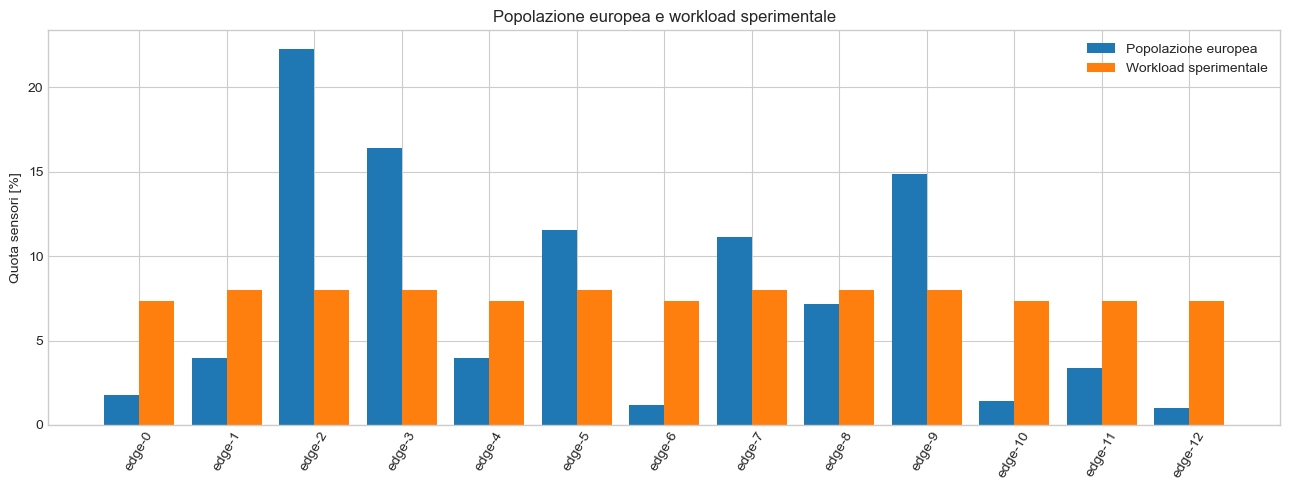

In [33]:
fig, ax = plt.subplots(figsize=(13, 5))

positions = np.arange(
    len(workload_by_edge)
)

width = 0.4


ax.bar(
    positions - width / 2,
    workload_by_edge['population_share_pct'],
    width,
    label='Popolazione europea',
)

ax.bar(
    positions + width / 2,
    workload_by_edge['workload_share_pct'],
    width,
    label='Workload sperimentale',
)


ax.set_xticks(
    positions,
    workload_by_edge['edge_id'],
    rotation=60,
)

ax.set(
    ylabel='Quota sensori [%]',
    title='Popolazione europea e workload sperimentale',
)

ax.legend()

plt.tight_layout()
plt.show()

## 8. Carico naturale del workload sperimentale

Il numero di sensori assegnato a ciascun Edge è pressoché uniforme, ma la frequenza naturale delle osservazioni può differire tra i singoli dispositivi.

Per questo motivo il bilanciamento del numero di sensori non implica necessariamente un bilanciamento del carico. A partire da `rows_per_day` viene quindi stimato, per ciascun Edge, il rate naturale medio di eventi al secondo generato dai sensori appartenenti al workload sperimentale.

La quota percentuale di carico permette di confrontare il contributo naturale dei diversi Edge prima dell'applicazione di qualsiasi accelerazione del replay.

In [34]:
workload_edge_summary = (
    experimental_workload
    .groupby(
        ['edge_cluster', 'edge_id'],
        as_index=False,
    )
    .agg(
        sensors=('sensor_id', 'nunique'),
        rows=('rows', 'sum'),
        rows_per_day=('rows_per_day', 'sum'),
    )
)

workload_edge_summary[
    'natural_events_per_second'
] = (
    workload_edge_summary['rows_per_day']
    / SECONDS_PER_DAY
)

natural_workload_events_per_second = (
    workload_edge_summary[
        'natural_events_per_second'
    ].sum()
)

workload_edge_summary['load_share_pct'] = (
    100
    * workload_edge_summary[
        'natural_events_per_second'
    ]
    / natural_workload_events_per_second
)

workload_edge_summary = (
    workload_edge_summary
    .sort_values('edge_cluster')
    .reset_index(drop=True)
)

workload_edge_summary

,edge_cluster,edge_id,sensors,rows,rows_per_day,natural_events_per_second,load_share_pct
0,0,edge-0,11,124410,"4,013.226",0.046,5.905
1,1,edge-1,12,171649,"5,537.065",0.064,8.147
2,2,edge-2,12,189420,"6,110.323",0.071,8.991
3,3,edge-3,12,145178,"4,683.161",0.054,6.891
4,4,edge-4,11,133862,"4,318.129",0.050,6.354
5,5,edge-5,12,145501,"4,693.581",0.054,6.906
6,6,edge-6,11,160171,"5,166.806",0.060,7.603
7,7,edge-7,12,149836,"4,833.419",0.056,7.112
8,8,edge-8,12,221171,"7,134.548",0.083,10.498
9,9,edge-9,12,155365,"5,011.774",0.058,7.375


## 9. Generazione degli artefatti per l'esecuzione

Il notebook genera gli artefatti necessari all'esecuzione dell'applicazione:

- `kmeans_topology.csv`, utilizzato da `deploygen` per ricavare gli Edge e il numero di sensori associato a ciascuno;
- gli shard di replay `edge-*.csv`, utilizzati direttamente dai Simulator tramite `REPLAY_FILE`.

Le metriche e i riepiloghi prodotti nelle sezioni precedenti rimangono nel notebook a scopo di analisi e non vengono esportati come artefatti runtime.

In [35]:
OUTPUT_DIR = DATASET_ROOT / 'output'

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

experimental_topology = (
    experimental_workload[[
        'sensor_id',
        'edge_id',
    ]]
    .sort_values('sensor_id')
    .reset_index(drop=True)
)

experimental_topology.to_csv(
    OUTPUT_DIR / 'kmeans_topology.csv',
    index=False,
)

experimental_topology.head()

,sensor_id,edge_id
0,12666,edge-6
1,13968,edge-5
2,16945,edge-3
3,19286,edge-2
4,19600,edge-6


### Generazione degli shard di replay

A partire dalla topologia sperimentale, il dataset sorgente viene nuovamente scandito a chunk mantenendo esclusivamente le osservazioni appartenenti ai 150 sensori selezionati e alla finestra temporale configurata.

Ogni osservazione viene scritta direttamente nello shard `edge-*.csv` associato all'Edge del relativo sensore.

Gli shard contengono solamente le informazioni necessarie al replay: identificativo del sensore, timestamp e misure di pressione, temperatura e umidità. A runtime ogni Simulator legge esclusivamente il proprio shard tramite `REPLAY_FILE`.

In [36]:
REPLAY_CHUNK_ROWS = 1_000_000

REPLAY_SHARD_DIR = (
    DATASET_ROOT
    / 'derived'
    / 'replay_by_edge'
)

sensor_to_edge = (
    experimental_topology
    .assign(
        sensor_id=lambda frame: (
            frame['sensor_id']
            .astype('string')
            .str.strip()
        )
    )
    .set_index('sensor_id')['edge_id']
)

In [37]:
REPLAY_SHARD_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# Elimina gli shard prodotti da eventuali esecuzioni precedenti.
for stale_shard in REPLAY_SHARD_DIR.glob(
    'edge-*.csv'
):
    stale_shard.unlink()

headers_written = set()

for chunk in pd.read_csv(
    CSV_PATH,
    sep=CSV_SEPARATOR,
    dtype='string',
    chunksize=REPLAY_CHUNK_ROWS,
    low_memory=False,
):
    filtered_chunk, _ = filter_chunk_by_time(
        chunk=chunk,
        time_start=TIME_WINDOW_START,
        time_end=TIME_WINDOW_END,
    )

    if filtered_chunk.empty:
        continue

    sensor_ids = (
        filtered_chunk['sensor_id']
        .str.strip()
    )

    assigned_edges = sensor_ids.map(
        sensor_to_edge
    )

    selected_rows = assigned_edges.notna()

    if not selected_rows.any():
        continue

    routed_chunk = (
        filtered_chunk.loc[
            selected_rows,
            REPLAY_COLUMNS,
        ]
        .copy()
    )

    routed_chunk['__edge_id'] = (
        assigned_edges.loc[
            selected_rows
        ].to_numpy()
    )

    for edge_id, edge_chunk in routed_chunk.groupby(
        '__edge_id',
        sort=False,
    ):
        shard_path = (
            REPLAY_SHARD_DIR
            / f'{edge_id}.csv'
        )

        first_write = edge_id not in headers_written

        edge_chunk[REPLAY_COLUMNS].to_csv(
            shard_path,
            sep=CSV_SEPARATOR,
            index=False,
            mode='w' if first_write else 'a',
            header=first_write,
        )

        headers_written.add(edge_id)

print(
    f'Generati {len(headers_written)} shard in '
    f'{REPLAY_SHARD_DIR}'
)

Generati 13 shard in C:\Users\aless\GolandProjects\ProgettoSDDC\Sensor\dataset\derived\replay_by_edge


## 10. Interpretazione architetturale

- La topologia Edge viene derivata dall'intera popolazione europea prima della costruzione del workload sperimentale.

- Il workload sperimentale contiene 150 sensori distribuiti in modo pressoché uniforme tra gli Edge. Questa scelta bilancia il numero di dispositivi per dominio, mentre il rate naturale degli eventi può comunque differire in funzione della frequenza di osservazione dei singoli sensori.

- I sensori selezionati mantengono l'assegnazione all'Edge ottenuta dal clustering dell'intera popolazione europea; il workload sperimentale non viene sottoposto a un nuovo clustering.

- `kmeans_topology.csv` rappresenta la topologia sperimentale utilizzata da `deploygen` per determinare gli Edge e il numero di sensori associato a ciascuno.

- Gli shard di replay vengono generati direttamente dal dataset sorgente mantenendo esclusivamente le osservazioni dei 150 sensori selezionati.

- Ogni Simulator legge esclusivamente il proprio file `edge-*.csv`, contenente gli eventi dei sensori assegnati al relativo Edge Site.